In [21]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [60]:
##IMPORTING THE CLEANED DATA
import pandas as pd
import numpy as np

data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

In [61]:
##CONVERTING TO DATETIME
data["DATE OCC"] = pd.to_datetime(data["DATE OCC"])

In [62]:
##CREATING TIME VARIABLES
data["year"] = data["DATE OCC"].dt.year
data["month"] = data["DATE OCC"].dt.month
data["day_of_week"] = data["DATE OCC"].dt.dayofweek

In [63]:
##ESTABLISHING SPATIAL GRID CELLS

##0.01 degrees ≈ ~1km
grid_size = 0.01

data["lat_grid"] = (data["LAT"] // grid_size) * grid_size
data["lon_grid"] = (data["LON"] // grid_size) * grid_size

In [64]:
##CREATING A SPATIOTEMPORAL DATASET

crime_grid = (
    data.groupby(["lat_grid","lon_grid","year","month"])
    .size()
    .reset_index(name="crime_count")
)
##each row should represent a grid-cell and a time period

In [65]:
# Create full monthly time index
all_months = pd.date_range(
    start=data["DATE OCC"].min(),
    end=data["DATE OCC"].max(),
    freq="MS"
)

# Create full grid-time combinations
grid_index = pd.MultiIndex.from_product(
    [crime_grid["lat_grid"].unique(),
     crime_grid["lon_grid"].unique(),
     all_months],
    names=["lat_grid","lon_grid","date"]
)

full_grid = pd.DataFrame(index=grid_index).reset_index()

# Extract year/month
full_grid["year"] = full_grid["date"].dt.year
full_grid["month"] = full_grid["date"].dt.month

# Merge with crime counts
crime_grid = full_grid.merge(
    crime_grid,
    on=["lat_grid","lon_grid","year","month"],
    how="left"
)

# Fill missing crime counts
crime_grid["crime_count"] = crime_grid["crime_count"].fillna(0)

In [66]:
##ADDING LAG FEATURES
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"])

crime_grid["lag_1"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(1)
crime_grid["lag_3"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(3)
crime_grid["lag_6"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(6)

In [67]:
crime_grid = crime_grid.groupby(["lat_grid","lon_grid"]).filter(
    lambda x: x["crime_count"].sum() > 0
)

<h2>Random Forest Model 1</h2>
<p>One of the first models</p>

In [68]:
crime_grid = crime_grid.dropna(subset=["lag_1","lag_3","lag_6"])

In [69]:
train = crime_grid[crime_grid["year"] < 2022]
test = crime_grid[crime_grid["year"] >= 2022]

print(train.shape)
print(test.shape)

(21168, 9)
(14112, 9)


In [70]:
features = ["lat_grid", "lon_grid", "month", "lag_1", "lag_3", "lag_6"]

X_train = train[features]
y_train = train["crime_count"]

X_test = test[features]
y_test = test["crime_count"]

In [71]:
##Fitting Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
##Prediciting
pred_rf = rf_model.predict(X_test)

In [73]:
##Evaluating

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest MAE: 1.1484170603776622
Random Forest RMSE: 2.1678931444979774


In [74]:
##Comparing To Baseline
mae = 1.0908197343812427
rmse = 2.3333593436303555

print("Baseline Regression MAE:", mae)
print("Baseline Regression RMSE:", rmse)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Baseline Regression MAE: 1.0908197343812427
Baseline Regression RMSE: 2.3333593436303555
Random Forest MAE: 1.1484170603776622
Random Forest RMSE: 2.1678931444979774


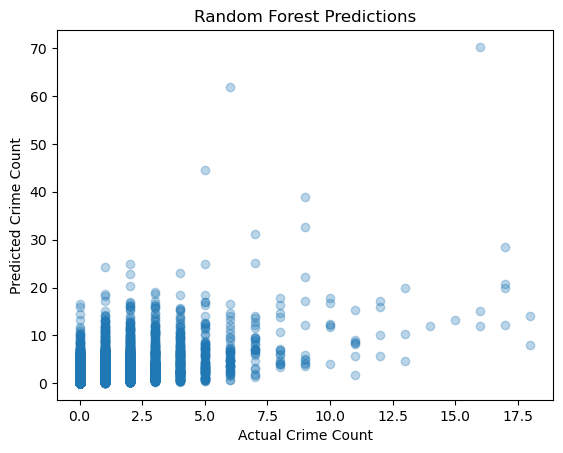

In [75]:
##Plotting Predicted vs Actual
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_rf, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest Predictions")
plt.show()

In [76]:
##Feature Importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
3,lag_1,0.658187
4,lag_3,0.162411
5,lag_6,0.096051
1,lon_grid,0.035039
0,lat_grid,0.025183
2,month,0.023129


<h3>Random Forest Model 2: Adding Rolling Features</h3>

In [84]:
# Sort first
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"]).copy()

# Group by grid cell
grouped = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"]

# Lag features if needed
crime_grid["lag_1"] = grouped.shift(1)
crime_grid["lag_3"] = grouped.shift(3)
crime_grid["lag_6"] = grouped.shift(6)

# Rolling features by grid cell
crime_grid["rolling_mean_3"] = grouped.transform(lambda x: x.shift(1).rolling(3).mean())
crime_grid["rolling_mean_6"] = grouped.transform(lambda x: x.shift(1).rolling(6).mean())
crime_grid["rolling_std_3"]  = grouped.transform(lambda x: x.shift(1).rolling(3).std())

In [85]:
crime_grid_model2 = crime_grid.dropna(subset=[
    "lag_1", "lag_3", "lag_6",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3"
]).copy()

In [86]:
features_v2 = [
    "lat_grid", "lon_grid", "month", "year",
    "lag_1", "lag_3", "lag_6",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3"
]

In [87]:
# make sure date is datetime
crime_grid_model2["date"] = pd.to_datetime(crime_grid_model2["date"])

# time-aware split
train = crime_grid_model2[crime_grid_model2["date"] < "2022-01-01"].copy()
test = crime_grid_model2[crime_grid_model2["date"] >= "2022-01-01"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train min/max:", train["date"].min(), train["date"].max())
print("Test min/max:", test["date"].min(), test["date"].max())

Train shape: (14112, 12)
Test shape: (14112, 12)
Train min/max: 2021-01-01 00:00:00 2021-12-01 00:00:00
Test min/max: 2022-01-01 00:00:00 2022-12-01 00:00:00


In [88]:
X_train = train[features_v2]
X_test = test[features_v2]
y_train = train["crime_count"]
y_test = test["crime_count"]

rf_model_v2.fit(X_train, y_train)
pred_rf_v2 = rf_model_v2.predict(X_test)

In [89]:
from sklearn.ensemble import RandomForestRegressor

rf_model_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model_v2.fit(X_train, y_train)
pred_rf_v2 = rf_model_v2.predict(X_test)

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf_v2 = mean_absolute_error(y_test, pred_rf_v2)
rmse_rf_v2 = np.sqrt(mean_squared_error(y_test, pred_rf_v2))

print("Random Forest V2 MAE:", mae_rf_v2)
print("Random Forest V2 RMSE:", rmse_rf_v2)

Random Forest V2 MAE: 1.164738480985446
Random Forest V2 RMSE: 2.3628338459516818


In [91]:
###COMPARISON
comparison = pd.DataFrame({
    "Model": ["Baseline Regression", "Random Forest V1", "Random Forest V2"],
    "MAE": [mae, mae_rf, mae_rf_v2],
    "RMSE": [rmse, rmse_rf, rmse_rf_v2]
})

comparison

,Model,MAE,RMSE
0,Baseline Regression,1.090820,2.333359
1,Random Forest V1,1.148417,2.167893
2,Random Forest V2,1.164738,2.362834


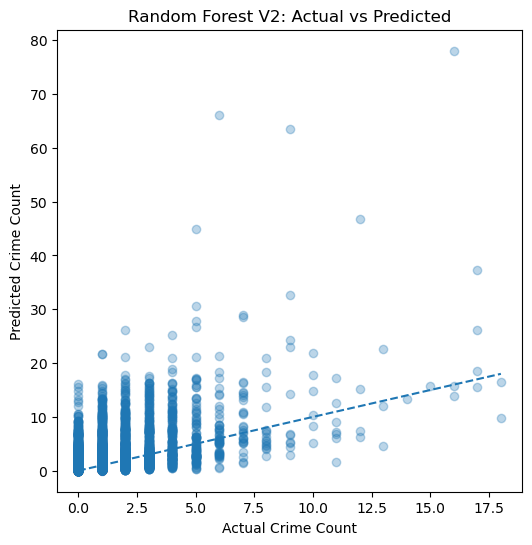

In [94]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf_v2, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest V2: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

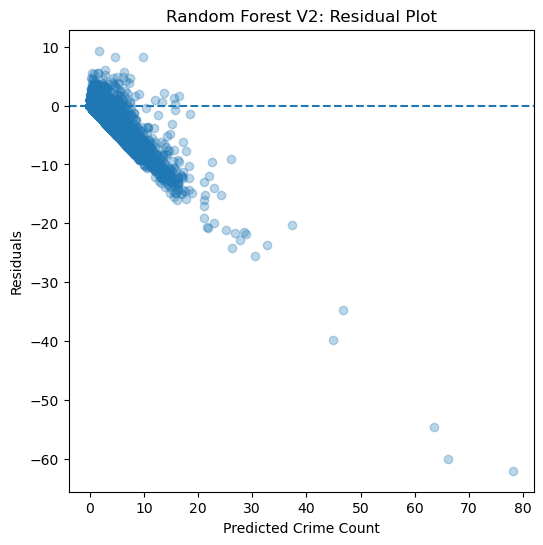

In [97]:
residuals_v2 = y_test - pred_rf_v2

plt.figure(figsize=(6,6))
plt.scatter(pred_rf_v2, residuals_v2, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Crime Count")
plt.ylabel("Residuals")
plt.title("Random Forest V2: Residual Plot")
plt.show()

In our random forest v2 we added rolling features. Due to the limit of time within our data set, rolling windows like 3 and 6 months, may smooth too much and overlap heavily with the lag features. We also dropped a good bit of data dropping the NANs.

<h3>Random Forest Model 3: Tuning the Model</h3>

In [93]:
rf_model_v3 = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model_v3.fit(X_train, y_train)
pred_rf_v3 = rf_model_v3.predict(X_test)

mae_rf_v3 = mean_absolute_error(y_test, pred_rf_v3)
rmse_rf_v3 = np.sqrt(mean_squared_error(y_test, pred_rf_v3))

print("Random Forest V3 MAE:", mae_rf_v3)
print("Random Forest V3 RMSE:", rmse_rf_v3)

Random Forest V3 MAE: 1.196368726673574
Random Forest V3 RMSE: 2.3750389883364713


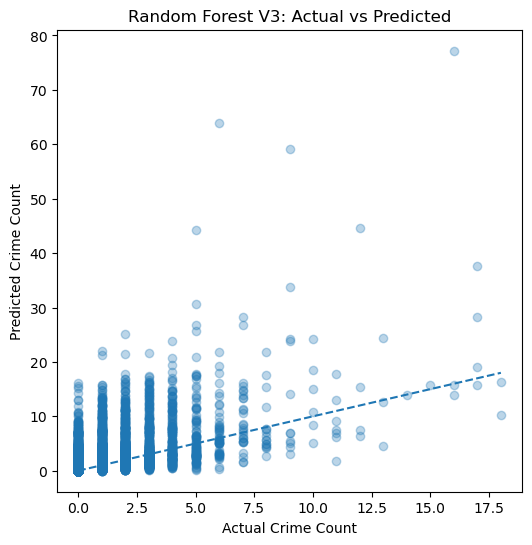

In [95]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf_v3, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest V3: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

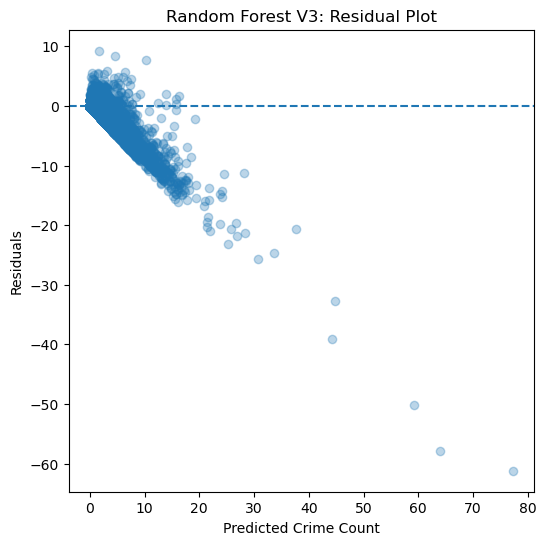

In [99]:
residuals_v3 = y_test - pred_rf_v3

plt.figure(figsize=(6,6))
plt.scatter(pred_rf_v3, residuals_v3, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Crime Count")
plt.ylabel("Residuals")
plt.title("Random Forest V3: Residual Plot")
plt.show()

A baseline linear regression model was first developed to provide an interpretable benchmark. A Random Forest model was then introduced to capture nonlinear relationships and interactions between temporal and spatial features. This model significantly improved RMSE compared to the baseline.

Additional feature engineering using rolling statistics and further hyperparameter tuning were explored; however, these modifications did not improve model performance. This suggests that lag-based features were sufficient to capture temporal dependencies, and that additional complexity introduced noise and reduced generalization.

As a result, the initial Random Forest model (V1) was selected as the final model due to its balance of performance, stability, and interpretability.